In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, f1_score
import matplotlib.pyplot as plt


Mounted at /content/drive


In [5]:
import pandas as pd

# Assuming your file is in Excel format, use read_excel
data = pd.read_csv('/content/drive/MyDrive/Thalassemia/Thalassemia2p.csv')
data.head()

,Gender,Type_of_Family,Occupational_Status,Area_of_Residence,Transfusion_Status,Frequency_of_Blood_Transfusion,Splenectomy_Status,Comorbidities_Status,Ironchelating_Therapy_Status,Medical_Expense,...,Physical_Functioning,Role_Physical,Bodily_Pain,Vitality,Mental_Health,Role_Emotional,Social_Functioning,Physical_Health_Summary,Total_SF_Score,Mental_Health_Status
0,0,2,1,1,0,0,0,3,0,180000,...,75,100,90.0,65,92,100.0,50.0,82.3,80.1,0
1,1,2,1,1,0,1,0,3,0,60000,...,100,100,100.0,90,92,100.0,50.0,94.0,89.6,0
2,0,2,1,0,0,1,0,3,0,96000,...,100,100,70.0,100,100,100.0,75.0,90.0,91.5,0
3,0,1,1,0,0,1,0,3,0,120000,...,100,100,100.0,90,92,100.0,52.5,94.0,89.9,0
4,1,2,1,1,0,0,1,3,0,150000,...,65,100,55.0,70,92,100.0,42.5,72.3,73.9,0


In [6]:
# Split features and target
X = data.drop('Mental_Health_Status', axis=1)
y = data['Mental_Health_Status']

# Display the encoded dataset
print(X)
print(y)

     Gender  Type_of_Family  Occupational_Status  Area_of_Residence  \
0         0               2                    1                  1   
1         1               2                    1                  1   
2         0               2                    1                  0   
3         0               1                    1                  0   
4         1               2                    1                  1   
..      ...             ...                  ...                ...   
351       0               0                    1                  0   
352       1               1                    1                  1   
353       0               2                    1                  1   
354       0               2                    1                  0   
355       0               2                    1                  0   

     Transfusion_Status  Frequency_of_Blood_Transfusion  Splenectomy_Status  \
0                     0                               0             

In [7]:
from sklearn.model_selection import train_test_split
# Split the data into train, test, and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [8]:
!pip install pyswarm

  Preparing metadata (setup.py) ... done
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4463 sha256=8e329a570f62a87c0ec7adf5ed8a19dd63c86791b83ec5e1fddc9f7f95afcd75
  Stored in directory: /root/.cache/pip/wheels/bb/4f/ec/8970b83323e16aa95034da175454843947376614d6d5e9627f
Successfully built pyswarm


In [9]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from pyswarm import pso
from imblearn.over_sampling import SMOTE

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Define the objective function for PSO to minimize the negative accuracy (maximize accuracy)
def objective_function(params):
    n_estimators = int(params[0])  # Number of estimators
    learning_rate = params[1]      # Learning rate
    max_depth = int(params[2])     # Maximum depth of trees

    # Initialize the LGBM classifier with the given parameters
    lgbm_classifier = LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=42
    )

    # Train the model on resampled training data
    lgbm_classifier.fit(X_train_res, y_train_res)

    # Evaluate on test set
    y_test_pred = lgbm_classifier.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_test_pred)

    # Return the negative of the accuracy because PSO minimizes the objective function
    return -accuracy

# Set the bounds for the parameters (n_estimators, learning_rate, max_depth)
lb = [10, 0.01, 3]  # Lower bounds for [n_estimators, learning_rate, max_depth]
ub = [200, 1.0, 15]  # Upper bounds for [n_estimators, learning_rate, max_depth]

# Run PSO to find the optimal hyperparameters
best_params, _ = pso(objective_function, lb, ub, swarmsize=10, maxiter=20)

# Extract the best parameters from the result
best_n_estimators = int(best_params[0])
best_learning_rate = best_params[1]
best_max_depth = int(best_params[2])

# Train the LGBM classifier with the optimized hyperparameters
lgbm_classifier = LGBMClassifier(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42
)
lgbm_classifier.fit(X_train_res, y_train_res)

# Evaluate on test set
y_test_pred = lgbm_classifier.predict(X_test)

# Calculate accuracy, precision, recall, and F1-score for test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)


# Calculate ROC curve and AUC for binary classification on test set
y_pred_probs = lgbm_classifier.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class (class 1)
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)


Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

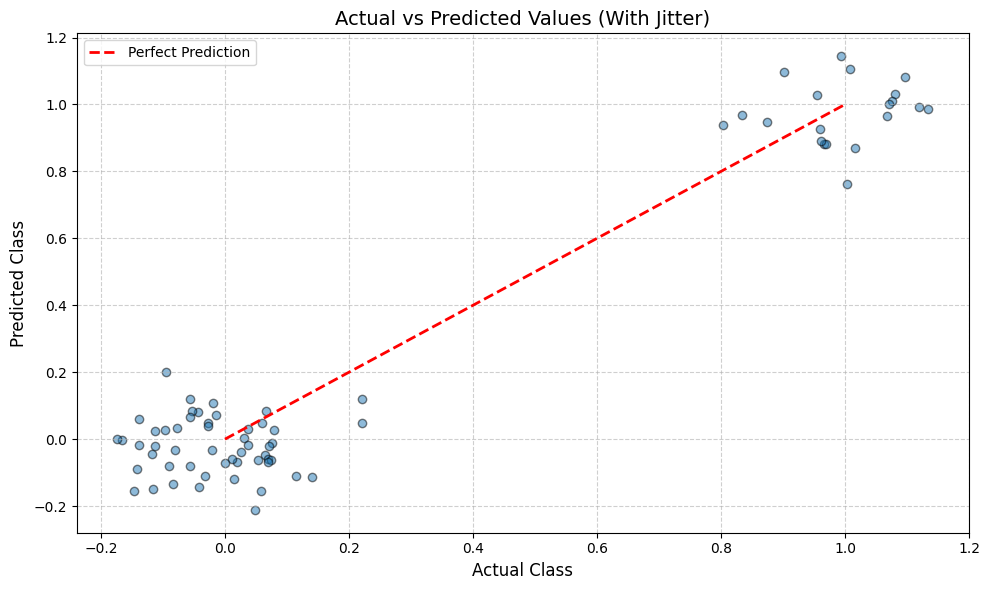

In [11]:
# Create a DataFrame for visualization
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

# Add jitter to avoid overlap
def add_jitter(arr, noise=0.1):
    return arr + np.random.normal(0, noise, size=arr.shape)

plt.figure(figsize=(10, 6))
plt.scatter(add_jitter(results_df['Actual']), add_jitter(results_df['Predicted']), alpha=0.5, edgecolors='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Values (With Jitter)', fontsize=14)
plt.xlabel('Actual Class', fontsize=12)
plt.ylabel('Predicted Class', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [13]:
from lightgbm import early_stopping, log_evaluation, record_evaluation

# Container to hold the log loss values
evals_result = {}

# Define the classifier
lgbm_classifier = LGBMClassifier(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42
)

# Train with evaluation logging
lgbm_classifier.fit(
    X_train_res, y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_test, y_test)],
    eval_metric='logloss',
    callbacks=[
        record_evaluation(evals_result),
        log_evaluation(period=10)
    ]
)


[LightGBM] [Info] Number of positive: 157, number of negative: 157
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 528
[LightGBM] [Info] Number of data points in the train set: 314, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

LGBMClassifier(learning_rate=np.float64(0.47622419752916995), max_depth=3,
               n_estimators=54, random_state=42)

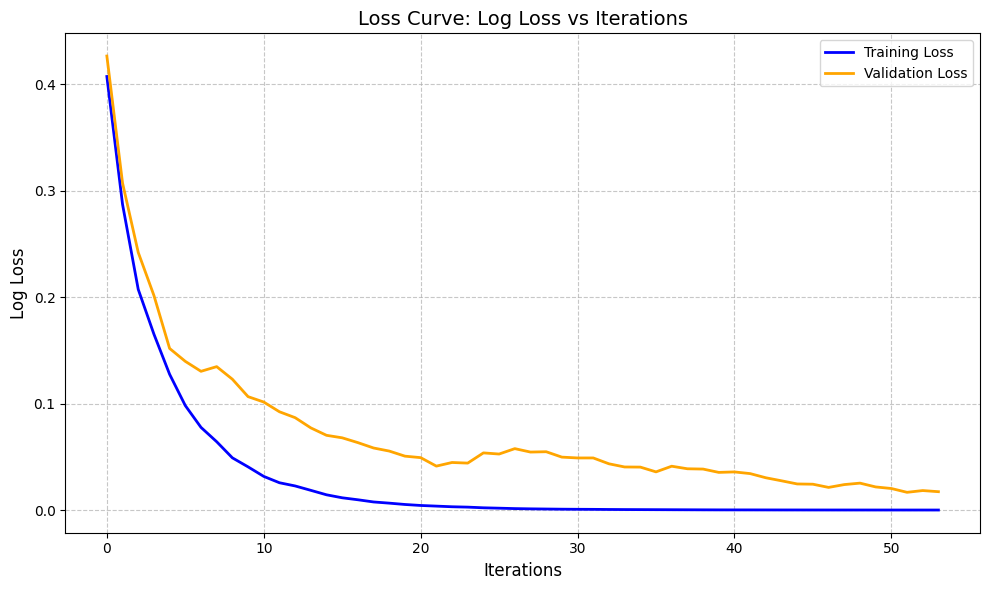

In [14]:
# Determine if binary or multi
loss_key = 'binary_logloss' if len(np.unique(y_train)) == 2 else 'multi_logloss'

# Extract loss curves
train_loss = evals_result['training'][loss_key]
val_loss = evals_result['valid_1'][loss_key]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Loss Curve: Log Loss vs Iterations', fontsize=14)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


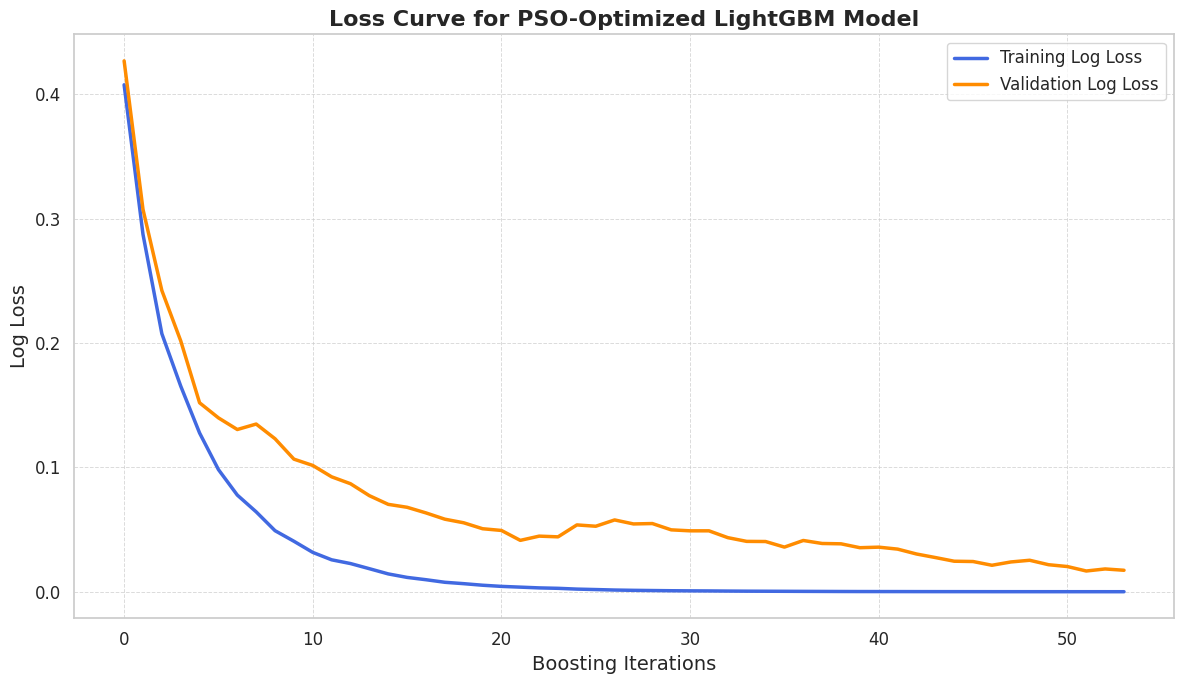

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn style for better visuals
sns.set(style="whitegrid")

# Determine loss key based on classification type
loss_key = 'binary_logloss' if len(np.unique(y_train)) == 2 else 'multi_logloss'

# Extract the loss values
train_loss = evals_result['training'][loss_key]
val_loss = evals_result['valid_1'][loss_key]

# Create the loss curve plot
plt.figure(figsize=(12, 7))
plt.plot(train_loss, label='Training Log Loss', color='royalblue', linewidth=2.5)
plt.plot(val_loss, label='Validation Log Loss', color='darkorange', linewidth=2.5)

# Titles and labels
plt.title('Loss Curve for PSO-Optimized LightGBM Model', fontsize=16, fontweight='bold')
plt.xlabel('Boosting Iterations', fontsize=14)
plt.ylabel('Log Loss', fontsize=14)

# Grid and legend
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

# Ticks formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Tight layout for publication
plt.tight_layout()

# Optional: Save high-quality image
plt.savefig('Loss_Curve_PSO_LightGBM.png', dpi=700)

# Show plot
plt.show()
